In [1]:
import os
import scipy
import random
import pandas as pd
import pickle as pkl
from training import *
from pylab import *
from scipy.stats import gaussian_kde
%matplotlib inline
from warnings import simplefilter
from sklearn.metrics import ConfusionMatrixDisplay, balanced_accuracy_score
# ignore all future warnings
simplefilter(action='ignore', category=UserWarning)

# Setup and Dataloading
[A] - specify training sites, test sites and non-predictive columns <br>
> *data_dir* is used to create a site list, NOTE: *data_dir* therefor needs to contain one subdir per site <cr> <br>
    
[B] - load csv file that contains all training data (csv created by notebooks 1 \& 2) <br>
> possibility to filter by class certainty

In [2]:
#[A]
data_dir = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/2_labelling/hp'
sites = os.listdir(data_dir)
test_sites = ['CG1-8B', 'F3-20B', 'CS-103A', 'ZF20-11A'] # Don't train on these
#train_sites = [s for s in sites if s not in test_sites]
#random.shuffle(train_sites)
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty', 'veg_class']
#print(train_sites)
#print(len(train_sites))

In [3]:
#[B]

#original (untargetted) data
results_dir = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/results/1_features/'
df = pd.read_csv(results_dir+'dataset_file_transformed.csv')
df_reduced = df[df['class_certainty'] <= 2]
non_predictive_columns = ['x_pos', 'y_pos', 'site', 'class_certainty', 'veg_class']

# Data with targetted labels added. Has extreme class imbalance
df_targetted = pd.read_csv(results_dir+'dataset_targetted_transformed.csv')
df_targetted_reduced = df_targetted[df_targetted['class_certainty'] <= 2]

In [4]:
sites = np.array(sites)
#shield
sites_shield = np.array(['CS-103A', 'CS-103B', 'CS-46A', 'CS-46B', 'CS-59B', 'CS-96B', 'CS117B', 'CS3A', 'CS3B', 'CS3C'])
test_sites_shield = ['CS-103A', 'CS-59B']
df_shield = df[df['site'].isin(sites_shield)]

#plain
sites_plain = [site for site in sites if site not in sites_shield]
test_sites_plain = ['CG1-8A', 'ZF20-6B', 'ZF46-18B']
df_plain = df[df['site'].isin(sites_plain)]
#df_plain["site"].unique() 

# Hyperparameter Search
We use a custom cross validataion (CV) and random search so that we can split the train and validation data by site. These functions are in training.py

# Experiments
Since the data has high spatial (and site-level) autocorrelation, we have a custom procedure for running experiments.
In the above section, we defined a site-level cross-validation routine, and nested that inside a custom hyperparameter search
that uses that CV. So for each experiment, we just need to implement the core training logic.

- define a function first
  - inputs:
    - model - initialized sklearn model
    - train_data - dataframe with all data for train sites
    - val_data - dataframe with all data for validation sites
  - outputs:
    - train accuracy
    - val accuracy
  - this function will be used within the CV loop, nested inside random search

- define the data you will use (+/- targetted labels for example)
- define model type and parameter distribution

This structure allows for maximum flexibility with how you define an experiment. When prototyping, it is easiest to not use the
CV functionality, and instead structure it like this:

```
def experiment_fn(model, train_data, val_data):
    ...
    ...
    return model.score(X_res, y_res), model.score(X_train, y_train)

model = RandomForestClassifier({params})

experiment_fn(model, df[df['site'].isin(train_sites)], df[df['site'].isin(test_sites)])

```

Once the training function is working as expected, try plugging it into the random search routine.

## Baseline
- Original data (without targetted lichen labels)
- Random Forest with moderate hyperparameter search
- SMOTE oversampling for underrepresented classes

In [5]:
model_type = RandomForestClassifier
cut_size=2
param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}
data = certainty_weight(df_plain)
#data = certainty_weight(df_targetted)
test_sites_exp = test_sites_plain

def experiment_fn(model, train_data, val_data, non_predictive_columns):
    print(train_data)
    X_train, y_train = split_xy(train_data, non_predictive_columns)
    X_val, y_val = split_xy(val_data, non_predictive_columns)
    #X_res, y_res = X_train, y_train
    
    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    over = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = over.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    model.fit(X_res.values, y_res.values)
    
    # -----------------------------------------------------------------------------------------------------------
    # Classifier performance
    #plot_test = model.predict(X_res)
    #print('actual values')
    #print(y_res)
    #print('predicted values')
    #print(plot_test)
    
    #fig, ax = plt.subplots()
    #ax = fig.addsubplot(111)
    #ax.plot(plot_test, y_res, '.')

    # -----------------------------------------------------------------------------------------------------------
    return model.score(X_res, y_res), model.score(X_val, y_val)

# Run hyperparameter search with CV
best_params = random_search(data, model_type, param_dist, experiment_fn, n_iterations=25, cut_size=cut_size, 
                                 test_sites=test_sites_exp, non_predictive_columns=non_predictive_columns)
experiment = model_best_params(data=data, test_sites=test_sites_exp, non_predictive_columns=non_predictive_columns, best_params=best_params)

save_dir = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/results/2b_classifier_performance/RF_generic/'
with open(save_dir+f'RF_experiment7b.pkl', 'wb') as file:
    pkl.dump(experiment, file)
    
'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

Trying {'n_estimators': 600, 'max_depth': 10, 'min_samples_split': 4, 'min_samples_leaf': 2}
           site  y_pos  x_pos  veg_class         R         G         B  chm  \
45       CG1-8B   2547   2686          1  0.952941  0.964706  0.874510    1   
46       CG1-8B   2547   2687          1  0.976471  0.984314  0.913725    1   
47       CG1-8B   2548   2686          1  0.952941  0.960784  0.882353    1   
48       CG1-8B   2548   2687          1  0.945098  0.945098  0.882353    1   
49       CG1-8B   3052   2830         12  0.501961  0.631373  0.454902    1   
...         ...    ...    ...        ...       ...       ...       ...  ...   
85214  ZF46-21B  15493   5964         12  0.733333  0.760784  0.611765    1   
85215  ZF46-21B  16885   3875          9  0.627451  0.584314  0.207843    1   
85216  ZF46-21B  16885   3876          9  0.552941  0.509804  0.129412    1   
85217  ZF46-21B  16886   3875          9  0.596078  0.560784  0.215686    1   
85218  ZF46-21B  16886   3876         

"\nmodel = model_type(n_estimators=500, max_depth=10, n_jobs=8)\nexperiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])\n"

In [6]:
save_dir = 'C:/Users/MABEB16/science/postdoc/5_projects/1_general_classifier/4_general_classifier/results/2b_classifier_performance/RF_generic/'
with open(save_dir+f'RF_experiment1.pkl', 'wb') as file:
    pkl.dump(experiment1, file)

{'n_estimators': 600, 'max_depth': 12, 'min_samples_split': 4, 'min_samples_leaf': 2}
0.7069391421513587


Text(0.5, 1.0, 'Confusion Matrix, Experiment 1, [%]')

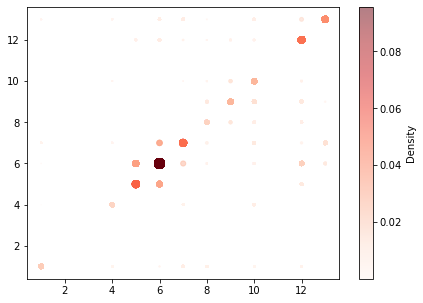

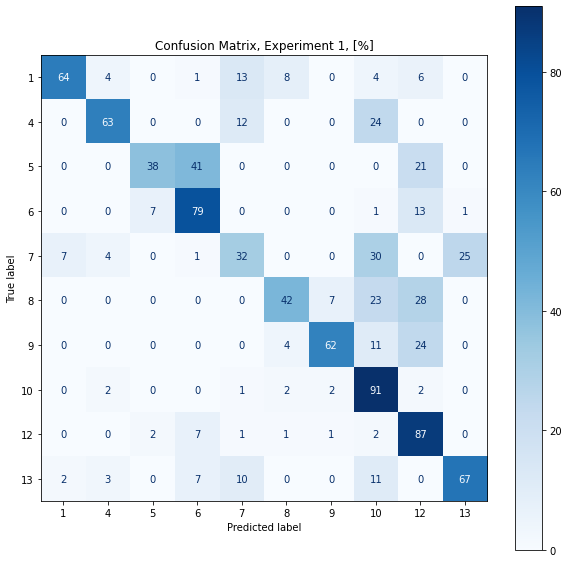

In [8]:


# train model
train_data = data[~data['site'].isin(test_sites)]
X_train, y_train = split_xy(train_data, non_predictive_columns)
model.fit(X_train.values, y_train.values)

# test data for model validation
test_data = data[data['site'].isin(test_sites)]
X_test, y_test = split_xy(test_data, non_predictive_columns)
predicted_values = model.predict(X_test.values)

# score
score = model.score(X_test, y_test)
print(score)

# plot predicted vs. true values
fig, ax = plt.subplots(figsize=(7, 5))
x = predicted_values
y = y_test
xy = np.vstack([x, y])
z = gaussian_kde(xy)(xy)
plt.scatter(x, y, c=z, s=1000*z, cmap='Reds', alpha=0.5)
plt.colorbar(label='Density')
#plot(predicted_values, y_test, '.')

#---------------------------------------------------------------------------------------------------------
# confusion matrix

#fig, ax = plt.subplots(figsize=(10, 10))
#ConfusionMatrixDisplay.from_estimator(model, X_test, y_test, cmap=plt.cm.Blues, normalize='true', ax=ax)
#display_labels=class_names,

# absolute confusion matrix
cfm = confusion_matrix(y_test, predicted_values,  labels = model.classes_)

# relative confusion matrix
samples_per_class = [sum(i) for i in cfm]
cfm_relativ = []
for i, line in enumerate(cfm):
    line_relative = [round(val/samples_per_class[i], 2)*100 for val in line]
    cfm_relativ.append(line_relative)

# plot relative confusion matrix
fig, ax = plt.subplots(figsize=(10, 10))
disp = ConfusionMatrixDisplay(confusion_matrix=np.array(cfm_relativ), display_labels=model.classes_)
disp.plot(cmap=plt.cm.Blues, ax=ax)
plt.title('Confusion Matrix, Experiment 1, [%]')

In [20]:
trues = [262, 142, 59, 1267, 86, 37, 228, 233, 518, 316]
totals = [sum(cfm[0]), sum(cfm[1]), sum(cfm[2]), sum(cfm[3]), sum(cfm[4]), sum(cfm[5]), sum(cfm[6]), sum(cfm[7]), sum(cfm[8]), sum(cfm[9])]

# random forest score 
print(sum(trues)/sum(totals))

# balanced accuracy
acc = [t/totals[i] for i, t in enumerate(trues)]
print(mean(acc))
acc_b = balanced_accuracy_score(y_test, predicted_values)
print(acc_b)

10 10
0.624509394387798
0.624509394387798
0.7069391421513587


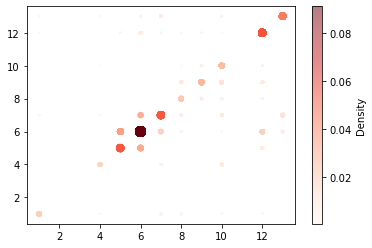

In [116]:




#density = plt.hist2d(predicted_values, y_test, bins=13)[0]
#plt.clf()  # Clear the histogram

#sizes = density  # Inverse relationship with density

#print(density)
#print(sizes)
#print(sizes.flatten()[np.searchsorted(np.sort(predicted_values), predicted_values)])

In [103]:
np.random.seed(42)
x = np.concatenate([np.random.normal(0, 1, 1000), np.random.normal(5, 1, 100)])
y = np.concatenate([np.random.normal(0, 1, 1000), np.random.normal(5, 1, 100)])

density = plt.hist2d(x, y, bins=10  )[0]
plt.clf()  # Clear the histogram

sizes = 1000 / (density + 10)  # Inverse relationship with density

#plt.scatter(x, y, s=sizes.flatten()[np.searchsorted(np.sort(x), x)], alpha=0.5)
#plt.title('Matplotlib Markers Size Adjusted for Data Density')
#plt.xlabel('X-axis')
#plt.ylabel('Y-axis')
#plt.text(2.5, 2.5, 'how2matplotlib.com', fontsize=12)
#print(density)
#print(sizes.flatten())
print(sizes.flatten()[np.searchsorted(np.sort(x), x)])

IndexError: index 692 is out of bounds for axis 0 with size 100

<Figure size 432x288 with 0 Axes>

## Weighted classes
This one seems to be going quite well.

In [ ]:
def experiment_fn(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    X_res, y_res = X_train, y_train

    model.fit(X_res.values, y_res.values)

    return model.score(X_res, y_res), model.score(X_val, y_val)


data = df_targetted_reduced

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [18, 20, 22, 24, 26, 28],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
    'class_weight': ['balanced', 'balanced_subsample'],
}

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, experiment_fn, n_iterations=25)

'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

## Naive targetted undersampling
- Targetted data included
- Random Forest with moderate hyperparameter search
- RandomUndersampler to balance lichen to other classes

In [ ]:
from imblearn.under_sampling import RandomUnderSampler

def experiment_fn(model, train_data, val_data):
    X_train, y_train = split_xy(train_data)
    X_val, y_val = split_xy(val_data)
    
    under = imblearn.under_sampling.RandomUnderSampler(sampling_strategy='majority')
    X_res, y_res = under.fit_resample(X_train, y_train)

    model.fit(X_res.values, y_res.values)

    return model.score(X_res, y_res), model.score(X_val, y_val)




data = df_targetted_reduced

model_type = RandomForestClassifier    

param_dist = { # discrete search space for random search
    'n_estimators': [400, 500, 600],
    'max_depth': [6, 8, 10, 12, 14],
    'min_samples_split': [2, 4],
    'min_samples_leaf': [1, 2],
}

# Run hyperparameter search with CV
random_search(data, model_type, param_dist, experiment_fn, n_iterations=5)

'''
model = model_type(n_estimators=500, max_depth=10, n_jobs=8)
experiment_fn(model, data[data['site'].isin(train_sites)], data[data['site'].isin(test_sites)])
'''

# Scratch Area
Playing around with the data, and informal experiments

In [ ]:
# Used for single experiments
def run_experiment(X_train, X_test, y_train, y_test, extra_metrics=False):
    # remove irrelevant columns
    X_train = X_train.drop(columns=non_predictive_columns)
    X_test = X_test.drop(columns=non_predictive_columns)

    # -------------------------------
    # oversample w synthetic minority oversampling to balance classes
    under = imblearn.over_sampling.SMOTE(sampling_strategy='not majority') # resamples all classes but majority
    X_res, y_res = under.fit_resample(X_train, y_train)

    # -----------------------------------------------------------------------------------------------------------
    # Train RF classifier
    clf=RandomForestClassifier(n_estimators=600, max_depth=6, n_jobs=12)
    clf.fit(X_res.values, y_res.values)

    # -----------------------------------------------------------------------------------------------------------
    # Prediction
    preds = clf.predict(X_test.values)

    print(f'  Train accuracy: {clf.score(X_res, y_res)}')
    print(f'  Test accuracy: {clf.score(X_test, y_test)}')

    if extra_metrics:
        # -----------------------------------------------------------------------------------------------------------
        # Inspect performance parameters: training and testing scores, confusion matrix, and feature importanceax1 = plt.figure(figsize=(5,5)).add_subplot(111)

        cf_matrix = confusion_matrix(y_test, preds,  labels = clf.classes_)
        disp = ConfusionMatrixDisplay(confusion_matrix=cf_matrix, display_labels=clf.classes_)
        disp.plot()
        plt.title('Confusion Matrix')

        feature_importance = pd.DataFrame(clf.feature_importances_, index=X_res.columns).sort_values(by=0, ascending=False)
        print(feature_importance)

    return clf, preds


X_train, X_test, y_train, y_test = split_by_sites(df_reduced, test_sites)10
model, _ = run_experiment(X_train, X_test, y_train, y_test, extra_metrics=True)

In [ ]:
df_majority = df[(df['veg_class'] == 1) & (df['class_certainty'] == 1)]
df_minority = df[(df['veg_class'] != 1) & (df['class_certainty'] <= 3)]

# Get count of minority class
minority_count = len(df_minority)

# Randomly sample from majority class to match the count of minority class
df_majority_downsampled = df_majority.sample(n=minority_count//3, random_state=42)

# Combine minority class with downsampled majority class
df_downsampled = pd.concat([df_majority_downsampled, df_minority])

# Shuffle the dataset
df_reduced = df_downsampled.sample(frac=1, random_state=42).reset_index(drop=True)
df_reduced['veg_class'].value_counts()